# 23CSE301 Machine Learning – Capstone Project

**Team No:** 8

**Project Title:** Healthcare Cost Prediction and Patient Risk Intelligence Platform

**Dataset:** Medical Insurance Cost Prediction Dataset (`medical_insurance.csv`)

**Target Variable:** `annual_medical_cost` (Regression Track)

### Project Introduction
Predicting patient healthcare costs helps insurance providers estimate liabilities and plan resources. In this notebook, we implement and compare all 10 required regression algorithms on held-out test data.

## Import Libraries
We import standard libraries and set `random_state=42`.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing
import app.utils as utils

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
print('Libraries imported successfully. Random seed set to 42.')

Libraries imported successfully. Random seed set to 42.


## Load Dataset and Dataset Audit
We load `medical_insurance.csv` and inspect dimensions, dtypes, missing values, and duplicates.

In [2]:
df_raw = pd.read_csv(config.DATA_PATH)
print('Dataset Shape (Rows, Columns):', df_raw.shape)
print('Missing Values:', df_raw.isnull().sum().sum())
print('Duplicates:', df_raw.duplicated().sum())
df_raw.head()

Dataset Shape (Rows, Columns): (100000, 54)
Missing Values: 30083


Duplicates: 0


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


## Data Preprocessing and Train Test Split
We split data into 80% train and 20% test splits (`random_state=42`). Preprocessing is fitted strictly on `X_train`.

In [3]:
X_train, X_test, y_train, y_test, cat_cols, num_cols, bin_cols = preprocessing.prepare_data_regression()
preprocessor = preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)
print('Train Set Shape:', X_train.shape)
print('Test Set Shape:', X_test.shape)

regression_results = []

Train Set Shape: (80000, 57)
Test Set Shape: (20000, 57)


## Regression Models
We train and evaluate each of the 10 required regression algorithms individually.

### 1. Linear Regression

In [4]:
m_lr = Pipeline([('prep', preprocessor), ('reg', LinearRegression())])
m_lr.fit(X_train, y_train)
p_lr = m_lr.predict(X_test)
r2_lr = r2_score(y_test, p_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, p_lr))
mae_lr = mean_absolute_error(y_test, p_lr)
regression_results.append({'Model': 'Linear Regression', 'R2': r2_lr, 'RMSE': rmse_lr, 'MAE': mae_lr})
print(f'Linear Regression -> R2: {r2_lr:.4f}, RMSE: {rmse_lr:.2f}, MAE: {mae_lr:.2f}')

Linear Regression -> R2: 0.9672, RMSE: 568.00, MAE: 317.16


### 2. Ridge Regression

In [5]:
m_ridge = Pipeline([('prep', preprocessor), ('reg', Ridge(alpha=1.0, random_state=42))])
m_ridge.fit(X_train, y_train)
p_ridge = m_ridge.predict(X_test)
r2_ridge = r2_score(y_test, p_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, p_ridge))
mae_ridge = mean_absolute_error(y_test, p_ridge)
regression_results.append({'Model': 'Ridge Regression', 'R2': r2_ridge, 'RMSE': rmse_ridge, 'MAE': mae_ridge})
print(f'Ridge Regression -> R2: {r2_ridge:.4f}, RMSE: {rmse_ridge:.2f}, MAE: {mae_ridge:.2f}')

Ridge Regression -> R2: 0.9672, RMSE: 568.00, MAE: 317.15


### 3. Lasso Regression

In [6]:
m_lasso = Pipeline([('prep', preprocessor), ('reg', Lasso(alpha=1.0, max_iter=2000, random_state=42))])
m_lasso.fit(X_train, y_train)
p_lasso = m_lasso.predict(X_test)
r2_lasso = r2_score(y_test, p_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, p_lasso))
mae_lasso = mean_absolute_error(y_test, p_lasso)
regression_results.append({'Model': 'Lasso Regression', 'R2': r2_lasso, 'RMSE': rmse_lasso, 'MAE': mae_lasso})
print(f'Lasso Regression -> R2: {r2_lasso:.4f}, RMSE: {rmse_lasso:.2f}, MAE: {mae_lasso:.2f}')

Lasso Regression -> R2: 0.9672, RMSE: 567.92, MAE: 315.50


### 4. ElasticNet Regression

In [7]:
m_enet = Pipeline([('prep', preprocessor), ('reg', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=2000, random_state=42))])
m_enet.fit(X_train, y_train)
p_enet = m_enet.predict(X_test)
r2_enet = r2_score(y_test, p_enet)
rmse_enet = np.sqrt(mean_squared_error(y_test, p_enet))
mae_enet = mean_absolute_error(y_test, p_enet)
regression_results.append({'Model': 'ElasticNet', 'R2': r2_enet, 'RMSE': rmse_enet, 'MAE': mae_enet})
print(f'ElasticNet -> R2: {r2_enet:.4f}, RMSE: {rmse_enet:.2f}, MAE: {mae_enet:.2f}')

ElasticNet -> R2: 0.9090, RMSE: 946.19, MAE: 548.96


### 5. Polynomial Regression

In [8]:
m_poly = Pipeline([('prep', preprocessor), ('poly', PolynomialFeatures(degree=2, include_bias=False)), ('reg', LinearRegression())])
m_poly.fit(X_train, y_train)
p_poly = m_poly.predict(X_test)
r2_poly = r2_score(y_test, p_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, p_poly))
mae_poly = mean_absolute_error(y_test, p_poly)
regression_results.append({'Model': 'Polynomial Regression', 'R2': r2_poly, 'RMSE': rmse_poly, 'MAE': mae_poly})
print(f'Polynomial Regression -> R2: {r2_poly:.4f}, RMSE: {rmse_poly:.2f}, MAE: {mae_poly:.2f}')

Polynomial Regression -> R2: 1.0000, RMSE: 0.04, MAE: 0.03


### 6. Decision Tree Regressor

In [9]:
m_dt = Pipeline([('prep', preprocessor), ('reg', DecisionTreeRegressor(max_depth=8, random_state=42))])
m_dt.fit(X_train, y_train)
p_dt = m_dt.predict(X_test)
r2_dt = r2_score(y_test, p_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, p_dt))
mae_dt = mean_absolute_error(y_test, p_dt)
regression_results.append({'Model': 'Decision Tree Regressor', 'R2': r2_dt, 'RMSE': rmse_dt, 'MAE': mae_dt})
print(f'Decision Tree Regressor -> R2: {r2_dt:.4f}, RMSE: {rmse_dt:.2f}, MAE: {mae_dt:.2f}')

Decision Tree Regressor -> R2: 0.9940, RMSE: 241.99, MAE: 113.14


### 7. Random Forest Regressor

In [10]:
m_rf = Pipeline([('prep', preprocessor), ('reg', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1))])
m_rf.fit(X_train, y_train)
p_rf = m_rf.predict(X_test)
r2_rf = r2_score(y_test, p_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, p_rf))
mae_rf = mean_absolute_error(y_test, p_rf)
regression_results.append({'Model': 'Random Forest Regressor', 'R2': r2_rf, 'RMSE': rmse_rf, 'MAE': mae_rf})
print(f'Random Forest Regressor -> R2: {r2_rf:.4f}, RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}')

Random Forest Regressor -> R2: 0.9978, RMSE: 145.89, MAE: 30.43


### 8. Gradient Boosting Regressor

In [11]:
m_gb = Pipeline([('prep', preprocessor), ('reg', GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42))])
m_gb.fit(X_train, y_train)
p_gb = m_gb.predict(X_test)
r2_gb = r2_score(y_test, p_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, p_gb))
mae_gb = mean_absolute_error(y_test, p_gb)
regression_results.append({'Model': 'Gradient Boosting Regressor', 'R2': r2_gb, 'RMSE': rmse_gb, 'MAE': mae_gb})
print(f'Gradient Boosting Regressor -> R2: {r2_gb:.4f}, RMSE: {rmse_gb:.2f}, MAE: {mae_gb:.2f}')

Gradient Boosting Regressor -> R2: 0.9838, RMSE: 398.65, MAE: 186.24


### 9. Support Vector Regressor

In [12]:
subsample_idx = np.random.choice(len(X_train), size=min(5000, len(X_train)), replace=False)
m_svr = Pipeline([('prep', preprocessor), ('reg', SVR(C=1000.0, epsilon=0.1))])
m_svr.fit(X_train.iloc[subsample_idx], y_train.iloc[subsample_idx])
p_svr = m_svr.predict(X_test)
r2_svr = r2_score(y_test, p_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, p_svr))
mae_svr = mean_absolute_error(y_test, p_svr)
regression_results.append({'Model': 'Support Vector Regressor', 'R2': r2_svr, 'RMSE': rmse_svr, 'MAE': mae_svr})
print(f'Support Vector Regressor -> R2: {r2_svr:.4f}, RMSE: {rmse_svr:.2f}, MAE: {mae_svr:.2f}')

Support Vector Regressor -> R2: 0.7074, RMSE: 1696.86, MAE: 453.62


### 10. KNN Regressor

In [13]:
m_knn = Pipeline([('prep', preprocessor), ('reg', KNeighborsRegressor(n_neighbors=7, n_jobs=-1))])
m_knn.fit(X_train.iloc[subsample_idx], y_train.iloc[subsample_idx])
p_knn = m_knn.predict(X_test)
r2_knn = r2_score(y_test, p_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, p_knn))
mae_knn = mean_absolute_error(y_test, p_knn)
regression_results.append({'Model': 'KNN Regressor', 'R2': r2_knn, 'RMSE': rmse_knn, 'MAE': mae_knn})
print(f'KNN Regressor -> R2: {r2_knn:.4f}, RMSE: {rmse_knn:.2f}, MAE: {mae_knn:.2f}')

KNN Regressor -> R2: 0.7575, RMSE: 1544.66, MAE: 965.69


## Regression Model Comparison
Consolidated DataFrame comparing all 10 regression models, ranked by R² score in descending order.

In [14]:
df_reg = pd.DataFrame(regression_results).sort_values(by='R2', ascending=False).reset_index(drop=True)
df_reg.index += 1
df_reg

,Model,R2,RMSE,MAE
1,Polynomial Regression,1.000000,0.039366,0.030748
2,Random Forest Regressor,0.997837,145.885151,30.427155
3,Decision Tree Regressor,0.994049,241.993471,113.137344
4,Gradient Boosting Regressor,0.983849,398.652682,186.239155
5,Lasso Regression,0.967223,567.918613,315.499771
6,Ridge Regression,0.967213,568.000188,317.148542
7,Linear Regression,0.967213,568.002878,317.156005
8,ElasticNet,0.909019,946.185547,548.957701
9,KNN Regressor,0.757527,1544.657937,965.685399
10,Support Vector Regressor,0.707389,1696.861117,453.616426


## Hyperparameter Tuning, Cross Validation & Visualizations
We tune Random Forest using `RandomizedSearchCV`, compute 5-fold cross-validation R² scores, and plot diagnostics.

In [15]:
rf_param_grid = {'reg__n_estimators': [50, 100], 'reg__max_depth': [10, 15, None], 'reg__min_samples_split': [2, 5]}
search = RandomizedSearchCV(m_rf, rf_param_grid, n_iter=4, cv=3, scoring='r2', random_state=42, n_jobs=-1)
search.fit(X_train.iloc[:10000], y_train.iloc[:10000])
best_rf_model = search.best_estimator_
print('Best RF Hyperparameters:', search.best_params_)

cv_scores = cross_val_score(best_rf_model, X_train.iloc[:10000], y_train.iloc[:10000], cv=5, scoring='r2')
print(f'5-Fold CV Mean R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Best RF Hyperparameters: {'reg__n_estimators': 100, 'reg__min_samples_split': 2, 'reg__max_depth': None}


5-Fold CV Mean R2: 0.9852 +/- 0.0093


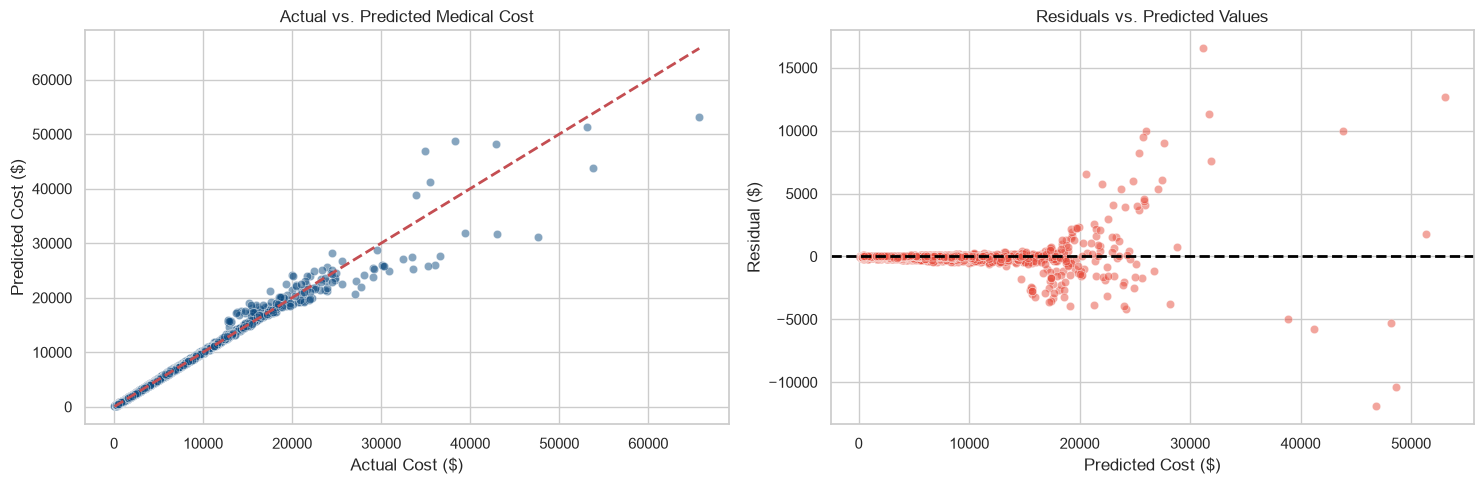

In [16]:
y_pred_best = best_rf_model.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.5, ax=axes[0], color='#0F4C81')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Medical Cost')
axes[0].set_xlabel('Actual Cost ($)')
axes[0].set_ylabel('Predicted Cost ($)')

sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.5, ax=axes[1], color='#E74C3C')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Cost ($)')
axes[1].set_ylabel('Residual ($)')
plt.tight_layout()
plt.show()